In [16]:
# BMW sales data analysis (2010-2024) with NumPy, pandas and matplotlib/seaborn
# Dataset: Kaggle "BMW Sales Data 2010-2024" (50,000 rows, 11 columns)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [18]:
# 1. Load and inspect
df = pd.read_csv("BMW_sales_data_2010-2024.csv")
print(df.shape)
print(df.info())
print(df.describe())

(50000, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Model                 50000 non-null  object 
 1   Year                  50000 non-null  int64  
 2   Region                50000 non-null  object 
 3   Color                 50000 non-null  object 
 4   Fuel_Type             50000 non-null  object 
 5   Transmission          50000 non-null  object 
 6   Engine_Size_L         50000 non-null  float64
 7   Mileage_KM            50000 non-null  int64  
 8   Price_USD             50000 non-null  int64  
 9   Sales_Volume          50000 non-null  int64  
 10  Sales_Classification  50000 non-null  object 
dtypes: float64(1), int64(4), object(6)
memory usage: 4.2+ MB
None
               Year  Engine_Size_L     Mileage_KM      Price_USD  Sales_Volume
count  50000.000000   50000.000000   50000.000000   50000.000000  5000

In [19]:
# 2. Clean: duplicates, missing values, consistent text
print("Missing values:\n", df.isna().sum())
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates().dropna()
for col in ["Model", "Region", "Fuel_Type", "Transmission"]:
    df[col] = df[col].str.strip()

Missing values:
 Model                   0
Year                    0
Region                  0
Color                   0
Fuel_Type               0
Transmission            0
Engine_Size_L           0
Mileage_KM              0
Price_USD               0
Sales_Volume            0
Sales_Classification    0
dtype: int64
Duplicate rows: 0


In [20]:
# 3. New columns with NumPy
df["Revenue_USD"] = df["Price_USD"] * df["Sales_Volume"]
df["Price_per_Liter"] = np.round(df["Price_USD"] / df["Engine_Size_L"], 2)

In [ ]:
# 4. Analysis
sales_by_year = df.groupby("Year")["Sales_Volume"].sum()
sales_by_region = df.groupby("Region")["Sales_Volume"].sum().sort_values(ascending=False)
top_models = df.groupby("Model")["Sales_Volume"].sum().sort_values(ascending=False).head(10)
fuel_by_year = df.pivot_table(index="Year", columns="Fuel_Type", values="Sales_Volume", aggfunc="sum")
corr = df[["Price_USD", "Engine_Size_L", "Mileage_KM", "Sales_Volume"]].corr()
 
print(sales_by_year)
print(sales_by_region)
print(top_models)
print(corr)

Year
2010    16933445
2011    16758941
2012    16751895
2013    16866733
2014    16958960
2015    17010207
2016    16957550
2017    16620811
2018    16412273
2019    17191956
2020    16310843
2021    16884666
2022    17920946
2023    16268654
2024    17527854
Name: Sales_Volume, dtype: int64
Region
Asia             42974277
Europe           42555138
North America    42402629
Middle East      42326620
Africa           41565252
South America    41551818
Name: Sales_Volume, dtype: int64
Model
7 Series    23786466
i8          23423891
X1          23406060
3 Series    23281303
i3          23133849
5 Series    23097519
M5          22779688
X3          22745529
X5          22709749
X6          22661986
Name: Sales_Volume, dtype: int64
               Price_USD  Engine_Size_L  Mileage_KM  Sales_Volume
Price_USD       1.000000       0.000146   -0.004238      0.000080
Engine_Size_L   0.000146       1.000000   -0.004906     -0.003942
Mileage_KM     -0.004238      -0.004906    1.000000      0.00143

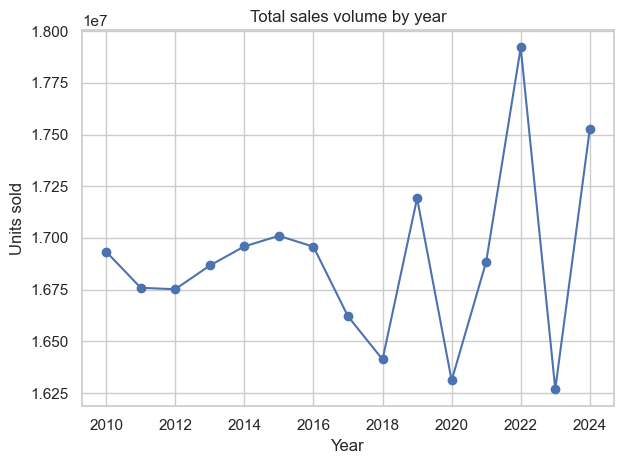

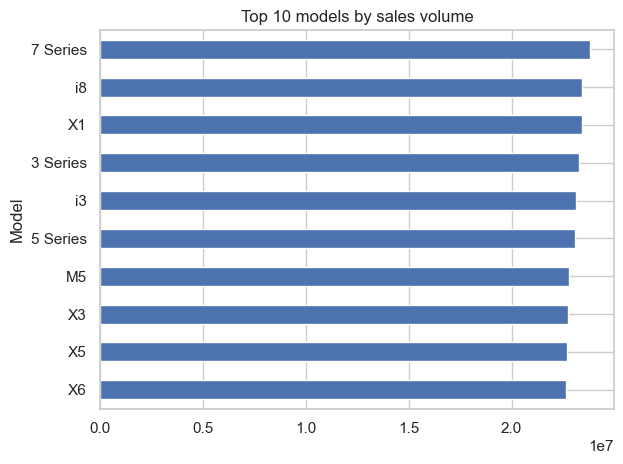

In [22]:
# 5. Visualizations
sales_by_year.plot(kind="line", marker="o", title="Total sales volume by year")
plt.ylabel("Units sold")
plt.tight_layout()
plt.savefig("sales_by_year.png", dpi=150)
plt.show()

top_models.plot(kind="barh", title="Top 10 models by sales volume")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("top_models.png", dpi=150)
plt.show()

## 6. Which regions and models lead?

Region
Asia             17.0
Europe           16.8
North America    16.7
Middle East      16.7
Africa           16.4
South America    16.4
Name: Sales_Volume, dtype: float64
Model
7 Series    9.4
i8          9.2
X1          9.2
3 Series    9.2
i3          9.1
Name: Sales_Volume, dtype: float64
       Region    Model  Sales_Volume
       Europe       i8       4202401
         Asia       X1       4192289
North America 7 Series       4087259
  Middle East 7 Series       4080751
South America       X6       4023804
       Africa 5 Series       4020702
Region
Asia             3250635961348
Europe           3188079573212
North America    3182938635076
Middle East      3167783530851
South America    3113805414620
Africa           3108999419352
Name: Revenue_USD, dtype: int64
Model
7 Series    1790070249282
3 Series    1768534028214
i8          1764743448529
X1          1752985285361
5 Series    1735712423092
Name: Revenue_USD, dtype: int64


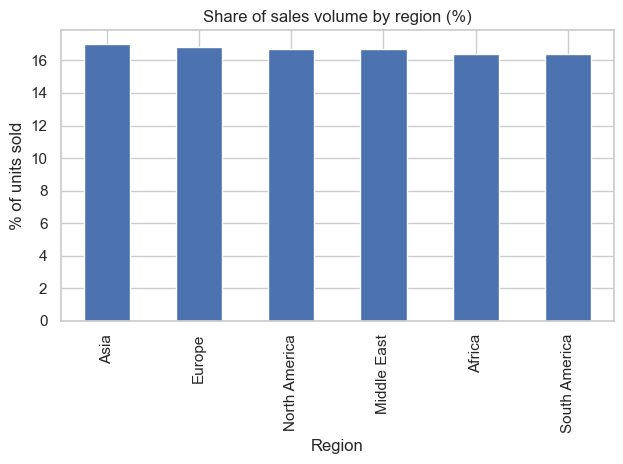

In [23]:
# 6. Share of total units by region and model
region_share = (sales_by_region / sales_by_region.sum() * 100).round(1)
model_sales = df.groupby("Model")["Sales_Volume"].sum().sort_values(ascending=False)
model_share = (model_sales / model_sales.sum() * 100).round(1)
print(region_share)
print(model_share.head(5))

# Top model in each region
top_model_per_region = (
    df.groupby(["Region", "Model"])["Sales_Volume"].sum()
    .reset_index()
    .sort_values("Sales_Volume", ascending=False)
    .drop_duplicates("Region")
)
print(top_model_per_region.to_string(index=False))

# Revenue leaders (price x units sold)
revenue_by_region = df.groupby("Region")["Revenue_USD"].sum().sort_values(ascending=False)
revenue_by_model = df.groupby("Model")["Revenue_USD"].sum().sort_values(ascending=False)
print(revenue_by_region)
print(revenue_by_model.head(5))

region_share.plot(kind="bar", title="Share of sales volume by region (%)")
plt.ylabel("% of units sold")
plt.tight_layout()
plt.savefig("region_share.png", dpi=150)
plt.show()

## 7. How do fuel types shift over time?

Fuel_Type  Diesel  Electric  Hybrid  Petrol
Year                                       
2010         24.1      24.8    26.1    25.0
2011         24.0      25.9    25.2    24.9
2012         24.4      25.3    26.0    24.3
2013         24.9      24.4    25.4    25.3
2014         26.7      23.7    26.1    23.4
2015         24.7      24.8    25.3    25.2
2016         25.1      24.8    24.2    25.9
2017         24.3      24.8    25.4    25.6
2018         23.7      26.4    24.5    25.4
2019         23.8      24.3    26.0    25.9
2020         25.5      24.3    24.7    25.5
2021         24.5      25.1    25.7    24.7
2022         25.0      24.5    26.2    24.4
2023         23.6      26.5    24.7    25.2
2024         24.9      24.5    26.5    24.2
Change in share, 2010 to 2024 (percentage points):
Fuel_Type
Petrol     -0.8
Electric   -0.4
Hybrid      0.4
Diesel      0.7
dtype: float64


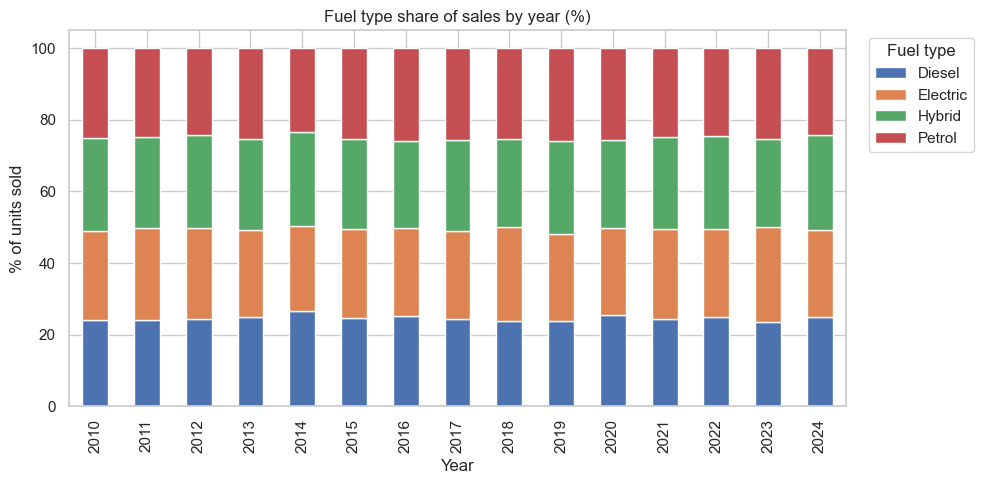

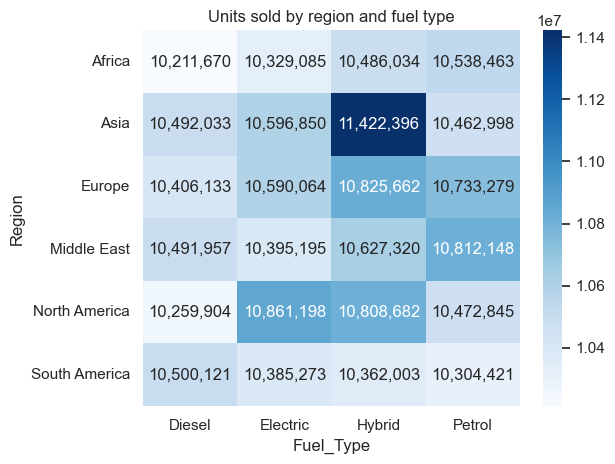

In [24]:
# 7. Fuel type share of yearly sales (%)
fuel_share = fuel_by_year.div(fuel_by_year.sum(axis=1), axis=0) * 100
print(fuel_share.round(1))

first, last = fuel_share.index.min(), fuel_share.index.max()
change = (fuel_share.loc[last] - fuel_share.loc[first]).round(1).sort_values()
print(f"Change in share, {first} to {last} (percentage points):")
print(change)

# 100% stacked bars: each bar is one year, colours are fuel types
fuel_share.plot(kind="bar", stacked=True, figsize=(10, 5), title="Fuel type share of sales by year (%)")
plt.ylabel("% of units sold")
plt.legend(title="Fuel type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("fuel_share_stacked.png", dpi=150)
plt.show()

# Fuel type by region (units sold)
region_fuel = df.pivot_table(index="Region", columns="Fuel_Type", values="Sales_Volume", aggfunc="sum")
sns.heatmap(region_fuel, annot=True, fmt=",.0f", cmap="Blues")
plt.title("Units sold by region and fuel type")
plt.tight_layout()
plt.savefig("region_fuel_heatmap.png", dpi=150)
plt.show()

## 8. Growth, pricing and statistical checks

Year
2010    NaN
2011   -1.0
2012   -0.0
2013    0.7
2014    0.5
2015    0.3
2016   -0.3
2017   -2.0
2018   -1.3
2019    4.8
2020   -5.1
2021    3.5
2022    6.1
2023   -9.2
2024    7.7
Name: Sales_Volume, dtype: float64


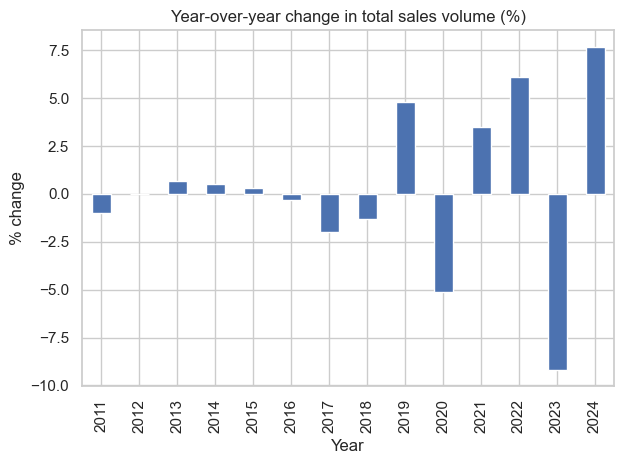

Fuel_Type
Electric    75276.0
Diesel      75080.0
Petrol      74990.0
Hybrid      74798.0
Name: Price_USD, dtype: float64
Model
7 Series    75570.0
3 Series    75566.0
i8          75366.0
5 Series    75288.0
X1          75262.0
Name: Price_USD, dtype: float64
Sales_Classification  High   Low
Region                          
Africa                29.9  70.1
Asia                  31.0  69.0
Europe                31.3  68.7
Middle East           29.9  70.1
North America         30.6  69.4
South America         30.2  69.8
ANOVA across regions: F = 0.87, p = 0.5029


In [25]:
# 8. Year-over-year change in total sales volume (%)
yoy = (sales_by_year.pct_change() * 100).round(1)
print(yoy)

yoy.dropna().plot(kind="bar", title="Year-over-year change in total sales volume (%)")
plt.ylabel("% change")
plt.tight_layout()
plt.savefig("yoy_change.png", dpi=150)
plt.show()

# Average price by fuel type and by model
print(df.groupby("Fuel_Type")["Price_USD"].mean().round(0).sort_values(ascending=False))
print(df.groupby("Model")["Price_USD"].mean().round(0).sort_values(ascending=False).head(5))

# Sales classification by region (% of rows)
class_by_region = pd.crosstab(df["Region"], df["Sales_Classification"], normalize="index") * 100
print(class_by_region.round(1))

# Are regional differences statistically meaningful? One-way ANOVA on sales volume per row
from scipy.stats import f_oneway
groups = [g["Sales_Volume"].values for _, g in df.groupby("Region")]
stat, p_value = f_oneway(*groups)
print(f"ANOVA across regions: F = {stat:.2f}, p = {p_value:.4f}")

## Key findings (from the results above)

- **Regions:** Asia leads with about 43.0M units (17.0% of the 253.4M total), but the gap to the lowest region (South America, 41.6M) is only about 3.4%. No region dominates.
- **Models:** the 7 Series is the top model (23.8M units), yet the top five models are within about 2.8% of each other.
- **Drivers of sales:** price, engine size and mileage show almost no correlation with sales volume (all correlations below 0.01 in absolute value).
- **Trend:** total yearly sales stayed between 16.3M and 17.9M units from 2010 to 2024, with no clear long-term growth or decline.
